# 04 · Monte Carlo loss distribution, dependence and uncertainty layers

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20)
from offshore_risk import load_config
cfg = load_config()
from offshore_risk.bayesian.calibration import apply_posteriors
from offshore_risk.simulation import simulate, SOURCES
from offshore_risk.financial.metrics import risk_metrics, tail_allocation
from offshore_risk.visualization import plots
cfg = apply_posteriors(cfg)
b = simulate(cfg, n_years=50_000, dependence='correlated')
a = simulate(cfg, n_years=50_000, dependence='independent')
pd.DataFrame({'Model A': risk_metrics(a.total), 'Model B': risk_metrics(b.total)}).T[['eal', 'median', 'p90', 'p95', 'p99', 'es99']] / 1e6

,eal,median,p90,p95,p99,es99
Model A,21.840416,13.669989,39.737386,55.649315,176.660530,347.384751
Model B,22.475677,13.446574,42.278312,60.643427,182.076116,353.082649


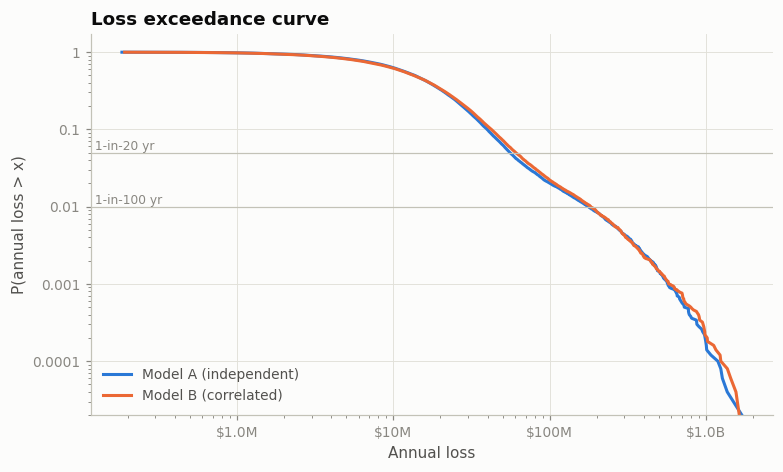

In [2]:
fig = plots.exceedance_curves({'Model A (independent)': a.total, 'Model B (correlated)': b.total})

Correlated year-level drivers raise the middle-to-upper part of the distribution (P90–P95, where years with several moderate events accumulate) but hardly change the extreme tail, which is set by single major-accident events.

In [3]:
tail_allocation(b.loss_by_source, SOURCES, 0.99)

,source,mean_loss,share_of_eal,es99_contribution,share_of_es99
0,release,7.964881e+06,0.354378,2.309255e+08,0.654027
1,compressor,5.285848e+06,0.235181,9.268108e+06,0.026249
2,weather,3.219111e+06,0.143226,4.038810e+06,0.011439
3,spurious_trip,2.864839e+06,0.127464,3.543913e+06,0.010037
4,pipeline,2.123994e+06,0.094502,9.966377e+07,0.282268
5,power_loss,7.411169e+05,0.032974,9.029029e+05,0.002557
6,collision,2.758879e+05,0.012275,4.739605e+06,0.013424


In [4]:
b.component_frame().mean().to_frame('mean USD/yr')

,mean USD/yr
property_damage,9.124020e+05
equipment_repair,1.067637e+06
emergency_response,3.180802e+05
logistics,1.868315e+05
restart,1.408263e+06
business_interruption,1.858246e+07
environmental_scenario,0.000000e+00


## Epistemic vs aleatory
Each 'world' fixes the uncertain parameters; the spread within a world is year-to-year randomness, the spread between worlds is what we do not know.

In [5]:
from offshore_risk.simulation.nested import run_nested
nr = run_nested(cfg, n_outer=150, n_inner=800)
nr.metric_summary()

,metric,p05,median,mean,p95,ratio_p95_p05
0,eal,1.422673e+07,2.236501e+07,2.286167e+07,3.417508e+07,2.402173
1,p95,3.561310e+07,5.616597e+07,6.080129e+07,9.776140e+07,2.745096
2,p99,7.929765e+07,1.595616e+08,1.738238e+08,3.219552e+08,4.060086
3,es99,1.675175e+08,3.073132e+08,3.429524e+08,6.602116e+08,3.941149


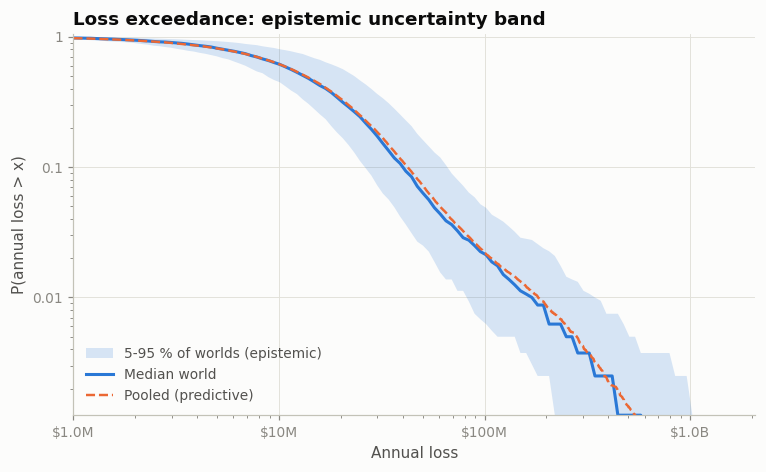

In [6]:
fig = plots.exceedance_band(nr, b.total)